# ARIMA Model Testing

In [6]:
import itertools
import logging
import os
import warnings

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv
from sklearn.metrics import r2_score
from statsmodels.tsa.statespace.sarimax import SARIMAX
from tqdm import tqdm

load_dotenv()

ROOT_PATH = os.path.dirname(os.getcwd())
DATA_FOLDER_PATH = os.path.join(ROOT_PATH, 'data', 'processed')

COVID_START = pd.Timestamp('2020-01-01')
COVID_END = pd.Timestamp('2021-12-31')
POST_COVID_START = pd.Timestamp('2022-01-01')

sns.set_palette('colorblind')
warnings.filterwarnings('ignore')
logging.getLogger('mlflow').setLevel(logging.ERROR)

mlflow.set_experiment('Brazil Tourism Forecasting ARIMA')

<Experiment: artifact_location='mlflow-artifacts:/3', creation_time=1781132358379, effective_trace_archival_retention=None, experiment_id='3', last_update_time=1781132358379, lifecycle_stage='active', name='Brazil Tourism Forecasting ARIMA', tags={}, trace_location=None, workspace='default'>

## Data Preparation

Several training data selections are evaluated in the grid search:

- **`last_{14,12,10,8,6,4}y_covid_exog`** — last N years of training data with a 0/1 COVID regressor to absorb the structural break
- **`post_covid`** — only post-COVID data (2022 onwards); no exog needed, cleaner signal

Evaluation metrics are computed on **test.parquet** (Jan–Jun 2025) for all models.

In [7]:
train_df = pd.read_parquet(os.path.join(DATA_FOLDER_PATH, 'train.parquet'))
train_monthly = train_df.set_index('date')[['arrival_count']].resample('ME').sum()
train_monthly['is_covid'] = (
    (train_monthly.index >= COVID_START) & (train_monthly.index <= COVID_END)
).astype(float)

test_df = pd.read_parquet(os.path.join(DATA_FOLDER_PATH, 'test.parquet'))
test_monthly = test_df.set_index('date')[['arrival_count']].resample('ME').sum()
test_monthly['is_covid'] = 0.0

window_years = [14, 12, 10, 8, 6, 4]
train_windows = {}
for years in window_years:
    start = train_monthly.index[-1] - pd.DateOffset(years=years)
    train_windows[years] = train_monthly[train_monthly.index >= start].copy()

train_post_covid = train_monthly[train_monthly.index >= POST_COVID_START].copy()

print(
    f'Full train  : {train_monthly.index[0].strftime("%b %Y")} → {train_monthly.index[-1].strftime("%b %Y")} ({len(train_monthly)} obs)'
)
for years in window_years:
    tw = train_windows[years]
    print(
        f'Last {years:>2}y    : {tw.index[0].strftime("%b %Y")} → {tw.index[-1].strftime("%b %Y")} ({len(tw)} obs, COVID obs: {int(tw["is_covid"].sum())})'
    )
print(
    f'Post-COVID  : {train_post_covid.index[0].strftime("%b %Y")} → {train_post_covid.index[-1].strftime("%b %Y")} ({len(train_post_covid)} obs)'
)
print(
    f'Test        : {test_monthly.index[0].strftime("%b %Y")} → {test_monthly.index[-1].strftime("%b %Y")} ({len(test_monthly)} obs)'
)

Full train  : Jan 1989 → Dec 2024 (432 obs)
Last 14y    : Dec 2010 → Dec 2024 (169 obs, COVID obs: 24)
Last 12y    : Dec 2012 → Dec 2024 (145 obs, COVID obs: 24)
Last 10y    : Dec 2014 → Dec 2024 (121 obs, COVID obs: 24)
Last  8y    : Dec 2016 → Dec 2024 (97 obs, COVID obs: 24)
Last  6y    : Dec 2018 → Dec 2024 (73 obs, COVID obs: 24)
Last  4y    : Dec 2020 → Dec 2024 (49 obs, COVID obs: 13)
Post-COVID  : Jan 2022 → Dec 2024 (36 obs)
Test        : Jan 2025 → Jun 2025 (6 obs)


## MLflow Setup

In [8]:
mlflow.set_tracking_uri('http://127.0.0.1:5000')
mlflow.statsmodels.autolog(log_models=True, log_datasets=False)

print(f'Tracking URI: {mlflow.get_tracking_uri()}')

Tracking URI: http://127.0.0.1:5000


## Model Selection Grid

Grid dimensions:
- **SARIMAX orders**: `p, q ∈ {0,1,2}`, `P, Q ∈ {0,1}`, `d=D=1` fixed from stationarity tests → 36 configs
- **Training data selection**: `last_14y/12y/10y/8y/6y/4y_covid_exog` or `post_covid` → 7 options
- **Total runs**: 252 — one MLflow run per (order, data selection)

In [9]:
d, D, s = 1, 1, 12

p_range = range(0, 3)
q_range = range(0, 3)
P_range = range(0, 2)
Q_range = range(0, 2)

sarimax_grid = list(itertools.product(p_range, q_range, P_range, Q_range))

data_configs = {}
for years in window_years:
    tw = train_windows[years]
    data_configs[f'last_{years}y_covid_exog'] = {
        'series': np.log(tw['arrival_count']),
        'exog_train': tw[['is_covid']],
        'exog_test': test_monthly[['is_covid']],
    }

data_configs['post_covid'] = {
    'series': np.log(train_post_covid['arrival_count']),
    'exog_train': None,
    'exog_test': None,
}

print(f'SARIMAX configs : {len(sarimax_grid)}')
print(f'Data selections : {len(data_configs)}')
print(f'Total runs      : {len(sarimax_grid) * len(data_configs)}')

SARIMAX configs : 36
Data selections : 7
Total runs      : 252


In [10]:
test_actual = test_monthly['arrival_count'].values
n_test = len(test_monthly)
results = []

for data_key, config in data_configs.items():
    for p, q, P, Q in tqdm(sarimax_grid, desc=f'[{data_key}]'):
        order = (p, d, q)
        seasonal_order = (P, D, Q, s)
        run_name = f'SARIMAX({p},{d},{q})({P},{D},{Q})[{s}] ({data_key})'

        with mlflow.start_run(run_name=run_name):
            mlflow.log_params({
                'p': p,
                'd': d,
                'q': q,
                'P': P,
                'D': D,
                'Q': Q,
                's': s,
                'transform': 'log',
                'data_selection': data_key,
                'exog': 'covid_indicator'
                if config['exog_train'] is not None
                else 'none',
                'n_train': len(config['series']),
                'n_test': n_test,
            })

            try:
                model = SARIMAX(
                    config['series'],
                    exog=config['exog_train'],
                    order=order,
                    seasonal_order=seasonal_order,
                    enforce_stationarity=False,
                    enforce_invertibility=False,
                )
                fit = model.fit(disp=False)

                forecast_log = fit.forecast(steps=n_test, exog=config['exog_test'])
                forecast = np.exp(forecast_log)

                rmse = float(np.sqrt(np.mean((test_actual - forecast) ** 2)))
                mae = float(np.mean(np.abs(test_actual - forecast)))
                mape = float(
                    np.mean(np.abs((test_actual - forecast) / test_actual)) * 100
                )
                r2 = float(r2_score(test_actual, forecast))

                mlflow.log_metrics({
                    'aic': fit.aic,
                    'bic': fit.bic,
                    'rmse': rmse,
                    'mae': mae,
                    'mape': mape,
                    'r2': r2,
                })

                results.append({
                    'data_selection': data_key,
                    'run_name': run_name,
                    'order': order,
                    'seasonal_order': seasonal_order,
                    'aic': fit.aic,
                    'bic': fit.bic,
                    'rmse': rmse,
                    'mae': mae,
                    'mape': mape,
                    'r2': r2,
                    'converged': True,
                })

            except Exception as exc:
                mlflow.log_param('error', str(exc)[:250])
                results.append({
                    'data_selection': data_key,
                    'run_name': run_name,
                    'order': order,
                    'seasonal_order': seasonal_order,
                    'aic': np.inf,
                    'bic': np.inf,
                    'rmse': np.inf,
                    'mae': np.inf,
                    'mape': np.inf,
                    'r2': -np.inf,
                    'converged': False,
                })

results_df = (
    pd.DataFrame(results).query('converged').sort_values('rmse').reset_index(drop=True)
)

print(f'Converged: {len(results_df)} / {len(sarimax_grid) * len(data_configs)}')
results_df.head(10)

[post_covid]: 100%|██████████| 36/36 [02:36<00:00,  4.36s/it]

Converged: 252 / 252


,data_selection,run_name,order,seasonal_order,aic,bic,rmse,mae,mape,r2,converged
0,last_8y_covid_exog,"SARIMAX(2,1,1)(1,1,0)[12] (last_8y_covid_exog)","(2, 1, 1)","(1, 1, 0, 12)",201.578720,215.069692,74240.825745,68778.876316,8.333584,0.965845,True
1,last_8y_covid_exog,"SARIMAX(2,1,2)(1,1,0)[12] (last_8y_covid_exog)","(2, 1, 2)","(1, 1, 0, 12)",202.857498,218.596965,79870.389268,71667.866776,8.043852,0.960468,True
2,last_10y_covid_exog,"SARIMAX(2,1,1)(1,1,0)[12] (last_10y_covid_exog)","(2, 1, 1)","(1, 1, 0, 12)",239.813006,255.072774,80202.749743,67992.564131,7.157324,0.960139,True
3,post_covid,"SARIMAX(2,1,2)(0,1,1)[12] (post_covid)","(2, 1, 2)","(0, 1, 1, 12)",-25.095212,-24.618563,87498.901223,80574.037078,10.592783,0.952556,True
4,post_covid,"SARIMAX(2,1,2)(1,1,1)[12] (post_covid)","(2, 1, 2)","(1, 1, 1, 12)",-26.858819,-26.302729,93076.777785,69293.253223,7.480396,0.946314,True
5,last_10y_covid_exog,"SARIMAX(1,1,2)(1,1,0)[12] (last_10y_covid_exog)","(1, 1, 2)","(1, 1, 0, 12)",243.326194,258.649455,99552.650691,73451.207316,7.228299,0.938584,True
6,last_8y_covid_exog,"SARIMAX(1,1,2)(1,1,0)[12] (last_8y_covid_exog)","(1, 1, 2)","(1, 1, 0, 12)",204.924801,218.500880,100194.729005,73898.938995,7.315829,0.937789,True
7,last_14y_covid_exog,"SARIMAX(2,1,1)(1,1,0)[12] (last_14y_covid_exog)","(2, 1, 1)","(1, 1, 0, 12)",312.250027,329.984990,104068.130853,76370.440530,7.792874,0.932886,True
8,last_12y_covid_exog,"SARIMAX(2,1,1)(1,1,0)[12] (last_12y_covid_exog)","(2, 1, 1)","(1, 1, 0, 12)",278.114605,294.738713,106475.536808,78465.658563,7.983409,0.929745,True
9,last_8y_covid_exog,"SARIMAX(2,1,0)(1,1,0)[12] (last_8y_covid_exog)","(2, 1, 0)","(1, 1, 0, 12)",202.146425,213.388901,108088.766331,79331.523762,7.980785,0.927600,True


## Results

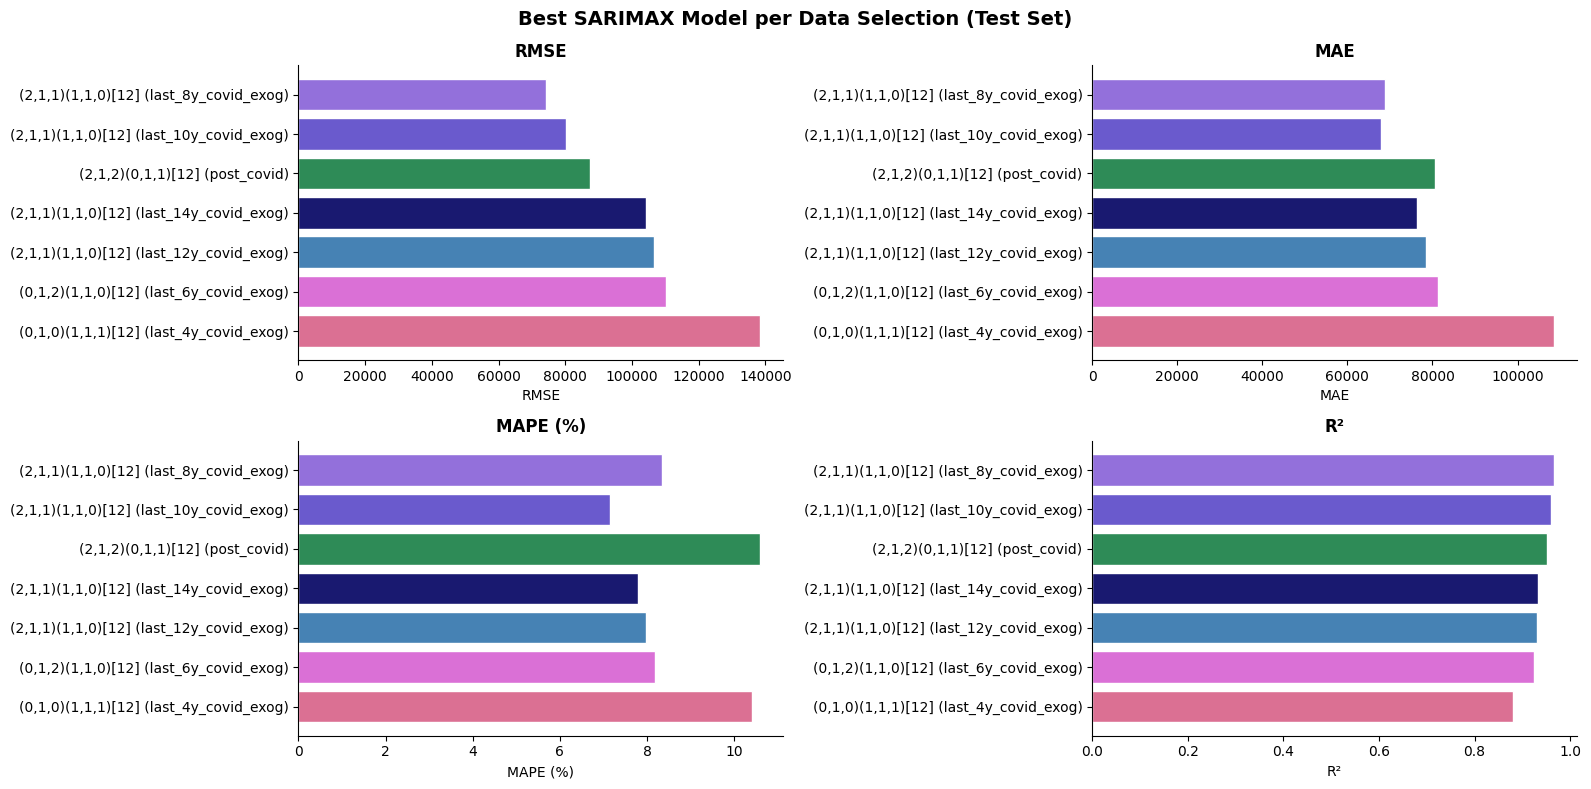

,data_selection,run_name,aic,bic,rmse,mae,mape,r2
0,last_8y_covid_exog,"SARIMAX(2,1,1)(1,1,0)[12] (last_8y_covid_exog)",201.578720,215.069692,74240.825745,68778.876316,8.333584,0.965845
1,last_10y_covid_exog,"SARIMAX(2,1,1)(1,1,0)[12] (last_10y_covid_exog)",239.813006,255.072774,80202.749743,67992.564131,7.157324,0.960139
2,post_covid,"SARIMAX(2,1,2)(0,1,1)[12] (post_covid)",-25.095212,-24.618563,87498.901223,80574.037078,10.592783,0.952556
3,last_14y_covid_exog,"SARIMAX(2,1,1)(1,1,0)[12] (last_14y_covid_exog)",312.250027,329.984990,104068.130853,76370.440530,7.792874,0.932886
4,last_12y_covid_exog,"SARIMAX(2,1,1)(1,1,0)[12] (last_12y_covid_exog)",278.114605,294.738713,106475.536808,78465.658563,7.983409,0.929745
5,last_6y_covid_exog,"SARIMAX(0,1,2)(1,1,0)[12] (last_6y_covid_exog)",113.379118,122.735123,110257.303459,81278.735972,8.186999,0.924666
6,last_4y_covid_exog,"SARIMAX(0,1,0)(1,1,1)[12] (last_4y_covid_exog)",-16.994621,-12.452645,138378.438665,108529.898978,10.415210,0.881338


In [12]:
palette = {
    'last_14y_covid_exog': 'midnightblue',
    'last_12y_covid_exog': 'steelblue',
    'last_10y_covid_exog': 'slateblue',
    'last_8y_covid_exog': 'mediumpurple',
    'last_6y_covid_exog': 'orchid',
    'last_4y_covid_exog': 'palevioletred',
    'post_covid': 'seagreen',
}

best_per_selection = (
    results_df
    .sort_values('rmse')
    .groupby('data_selection', sort=False)
    .first()
    .reset_index()
    .sort_values('rmse')
    .reset_index(drop=True)
)
best_per_selection['label'] = best_per_selection['run_name'].str.replace(
    'SARIMAX', '', regex=False
)
bar_colors = [palette[ds] for ds in best_per_selection['data_selection'][::-1]]

fig, axes = plt.subplots(2, 2, figsize=(16, 8))
fig.suptitle(
    'Best SARIMAX Model per Data Selection (Test Set)',
    fontsize=14,
    fontweight='bold',
)

for ax, (col, title) in zip(
    axes.flat, [('rmse', 'RMSE'), ('mae', 'MAE'), ('mape', 'MAPE (%)'), ('r2', 'R²')]
):
    ax.barh(
        best_per_selection['label'][::-1],
        best_per_selection[col][::-1],
        color=bar_colors,
        edgecolor='white',
    )
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel(title)
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

display(
    best_per_selection[
        ['data_selection', 'run_name', 'aic', 'bic', 'rmse', 'mae', 'mape', 'r2']
    ]
)

## Best Model Diagnostics

In [13]:
best_model = results_df.sort_values('rmse').iloc[0]

display(
    best_model[
        ['data_selection', 'run_name', 'aic', 'bic', 'rmse', 'mae', 'mape', 'r2']
    ]
    .to_frame()
    .T
)

,data_selection,run_name,aic,bic,rmse,mae,mape,r2
0,last_8y_covid_exog,"SARIMAX(2,1,1)(1,1,0)[12] (last_8y_covid_exog)",201.57872,215.069692,74240.825745,68778.876316,8.333584,0.965845


In [17]:
def fit_model(row, configs):
    cfg = configs[row['data_selection']]
    return SARIMAX(
        cfg['series'],
        exog=cfg['exog_train'],
        order=row['order'],
        seasonal_order=row['seasonal_order'],
        enforce_stationarity=False,
        enforce_invertibility=False,
    ).fit(disp=False)


best_fit = fit_model(best_model, data_configs)

print(f'[{best_model["data_selection"]}] {best_model["run_name"]}')
best_fit.summary()

[last_8y_covid_exog] SARIMAX(2,1,1)(1,1,0)[12] (last_8y_covid_exog)


<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:                       arrival_count   No. Observations:                   97
Model:             SARIMAX(2, 1, 1)x(1, 1, [], 12)   Log Likelihood                 -94.789
Date:                             qua, 10 jun 2026   AIC                            201.579
Time:                                     22:24:49   BIC                            215.070
Sample:                                 12-31-2016   HQIC                           206.937
                                      - 12-31-2024                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
is_covid      -0.7765      0.792     -0.981      0.327      -2.328       0.775
ar.L1          1.0159      0.226      4.501      0.000       0.573       1.458
ar.L2         -0.2636      0.159     -1.661      0.097      -0.575       0.048
ma.L1         -1.0772      0.209     -5.158      0.000      -1.487      -0.668
ar.S.L12      -0.4549      0.064     -7.066      0.000      -0.581      -0.329
sigma2         0.7519      0.252      2.988      0.003       0.259       1.245
===================================================================================
Ljung-Box (L1) (Q):                   0.17   Jarque-Bera (JB):              1275.22
Prob(Q):                              0.68   Prob(JB):                         0.00
Heteroskedasticity (H):               0.02   Skew:                            -2.32
Prob(H) (two-sided):                  0.00   Kurtosis:                        23.39
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

### Residual Diagnostics

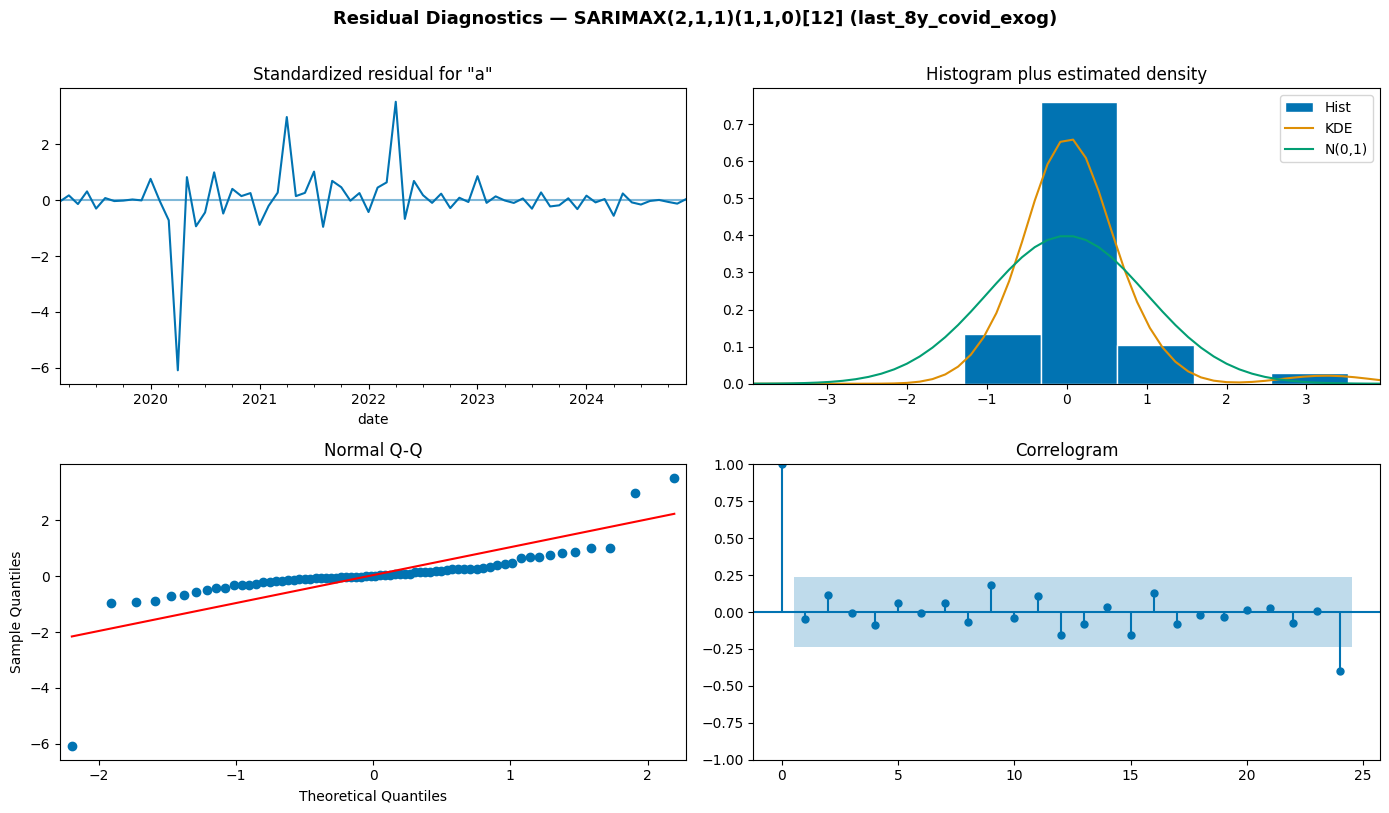

In [15]:
fig = best_fit.plot_diagnostics(figsize=(14, 8), lags=24)
fig.suptitle(
    f'Residual Diagnostics — {best_model["run_name"]}',
    fontsize=13,
    fontweight='bold',
    y=1.01,
)
plt.tight_layout()
plt.show()

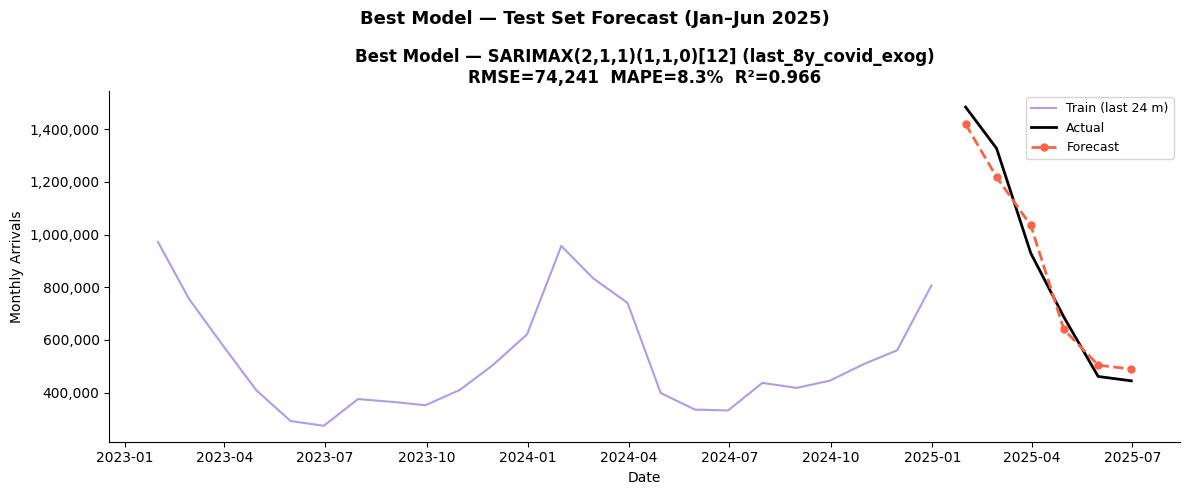

In [16]:
cfg = data_configs[best_model['data_selection']]
forecast_log = best_fit.forecast(steps=n_test, exog=cfg['exog_test'])
forecast = np.exp(forecast_log)
train_plot = np.exp(cfg['series']).iloc[-24:]

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    train_plot.index,
    train_plot.values,
    label='Train (last 24 m)',
    linewidth=1.5,
    color=palette[best_model['data_selection']],
    alpha=0.7,
)
ax.plot(
    test_monthly.index,
    test_monthly['arrival_count'],
    label='Actual',
    linewidth=2,
    color='black',
)
ax.plot(
    test_monthly.index,
    forecast,
    label='Forecast',
    linewidth=2,
    linestyle='--',
    color='tomato',
    marker='o',
    markersize=5,
)

ax.set_title(
    f'Best Model — {best_model["run_name"]}\n'
    f'RMSE={best_model["rmse"]:,.0f}  MAPE={best_model["mape"]:.1f}%  R²={best_model["r2"]:.3f}',
    fontsize=12,
    fontweight='bold',
)
ax.set_xlabel('Date')
ax.set_ylabel('Monthly Arrivals')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(fontsize=9)
sns.despine(ax=ax)

fig.suptitle(
    'Best Model — Test Set Forecast (Jan–Jun 2025)',
    fontsize=13,
    fontweight='bold',
)
plt.tight_layout()
plt.show()